In [1]:
# Load dataset, view info
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/himelsarder/coffee-shop-daily-revenue-prediction-dataset/coffee_shop_revenue.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB
None


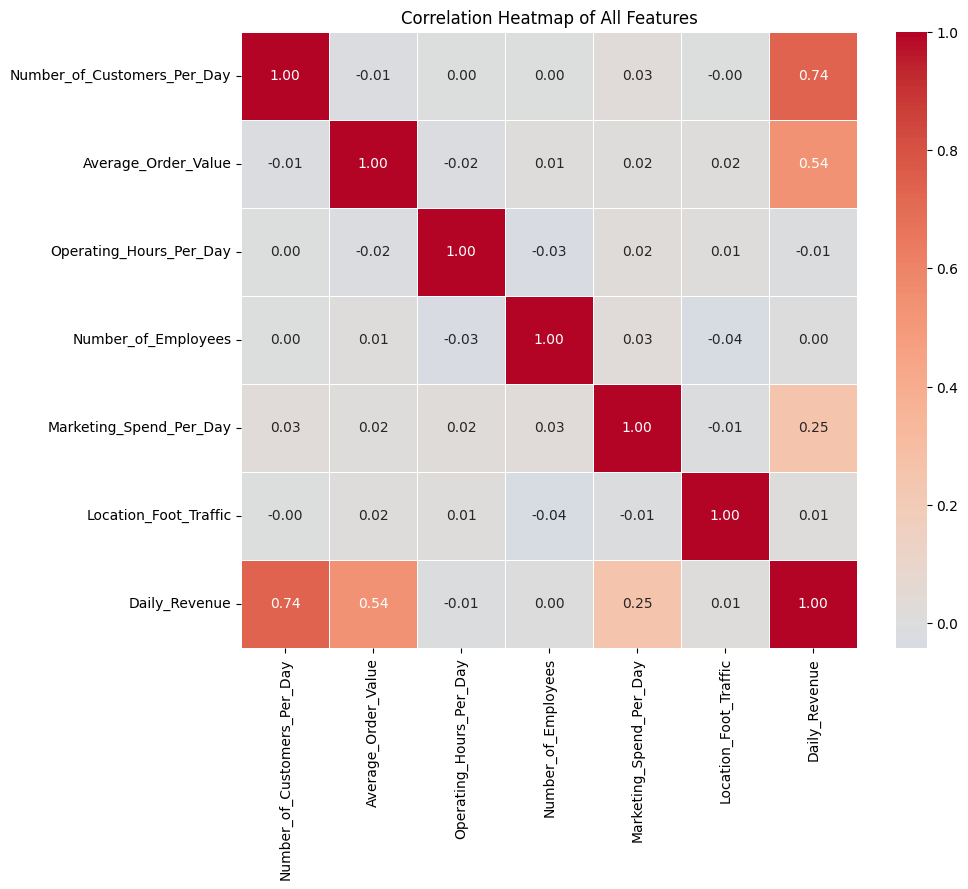

In [19]:
# Compute correlation matrix
corr_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.show()

In [20]:
# Set threshold for weak-but-not-negligible correlations (absolute value)
threshold = 0.1

# Create a DataFrame of pairs where |correlation| > threshold, excluding self-correlations
filtered_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # upper triangle only
    .stack()  # convert to long format
    .reset_index()  # make a DataFrame
)

filtered_corr.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Filter by absolute value
filtered_corr = filtered_corr[filtered_corr['Correlation'].abs() > threshold]

# Sort by absolute value descending
filtered_corr = filtered_corr.reindex(filtered_corr['Correlation'].abs().sort_values(ascending=False).index)

print(filtered_corr)

                     Variable 1     Variable 2  Correlation
5   Number_of_Customers_Per_Day  Daily_Revenue     0.736461
10          Average_Order_Value  Daily_Revenue     0.535694
19      Marketing_Spend_Per_Day  Daily_Revenue     0.254812


**Exploratory Correlation Analysis:**

* Number_of_Customers_Per_Day (r ≈ 0.736) and Average_Order_Value (r ≈ 0.536) are strong predictors of revenue.
* Marketing_Spend_Per_Day (r ≈ 0.255) is a weaker predictor, but still above the “weak-but-not-negligible” threshold of |r| = 0.1
* All other correlations have |r| < 0.1, so including them is unlikely to add predictive value.

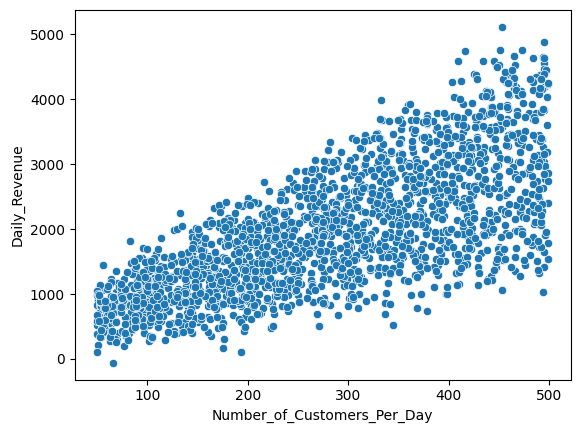

In [6]:
# Visualize relationship between number of customers and daily revenue

sns.scatterplot(x='Number_of_Customers_Per_Day', y='Daily_Revenue', data=df)
plt.show()


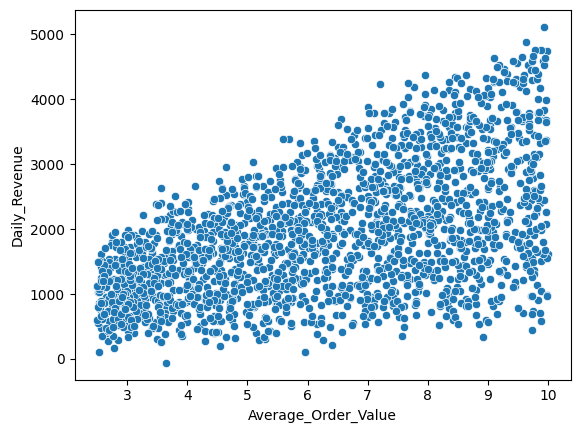

In [24]:
# Visualize relationship between average order value and daily revenue

sns.scatterplot(x='Average_Order_Value', y='Daily_Revenue', data=df)
plt.show()


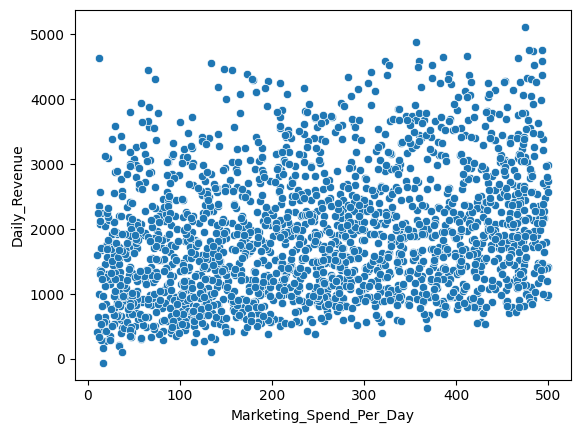

In [25]:
# Visualize relationship between daily marketing expenditure and daily revenue

sns.scatterplot(x='Marketing_Spend_Per_Day', y='Daily_Revenue', data=df)
plt.show()


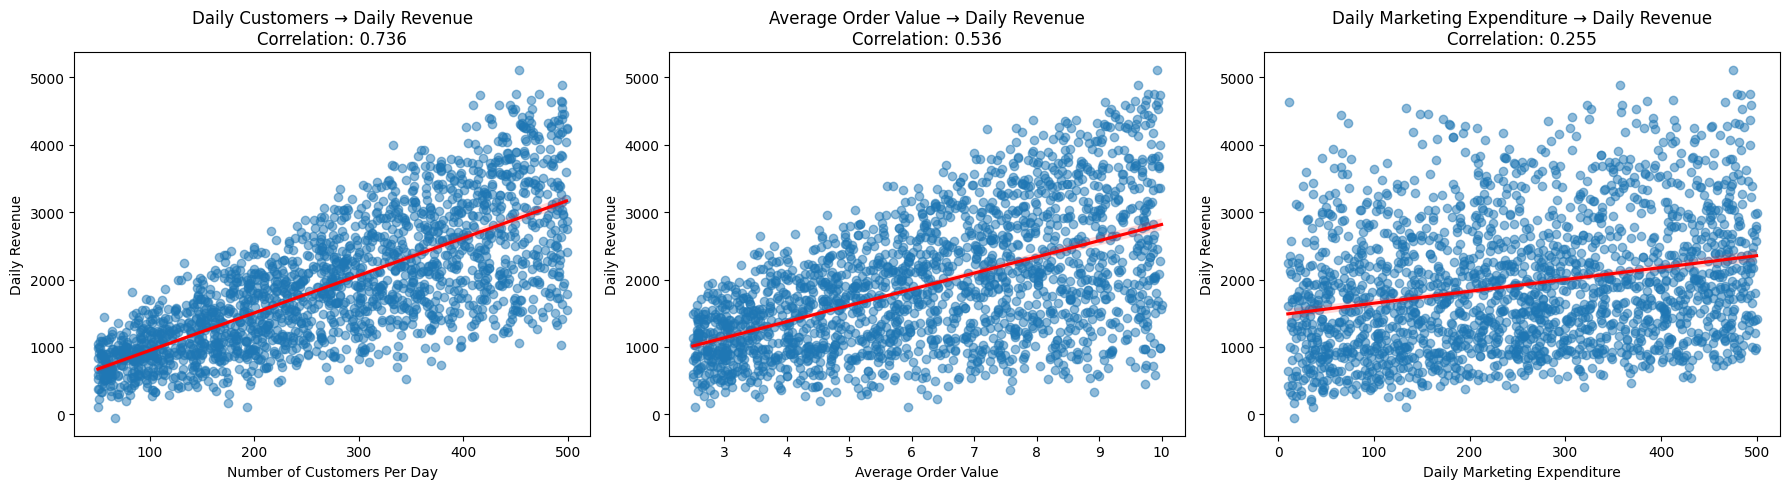

In [22]:
# Explopre the variables visually with regression lines.
# Create figure with 3 subplots to examine relationships with other key metrics.
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Foot Traffic → Customers
sns.regplot(x='Number_of_Customers_Per_Day', y='Daily_Revenue', data=df, ax=axes[0], line_kws={"color":"red"}, scatter_kws={"alpha":0.5})
corr1 = df['Number_of_Customers_Per_Day'].corr(df['Daily_Revenue'])
axes[0].set_title(f'Daily Customers → Daily Revenue\nCorrelation: {corr1:.3f}')
axes[0].set_xlabel('Number of Customers Per Day')
axes[0].set_ylabel('Daily Revenue')

# 2. Customers → Daily Revenue
sns.regplot(x='Average_Order_Value', y='Daily_Revenue', data=df, ax=axes[1], line_kws={"color":"red"}, scatter_kws={"alpha":0.5})
corr2 = df['Average_Order_Value'].corr(df['Daily_Revenue'])
axes[1].set_title(f'Average Order Value → Daily Revenue\nCorrelation: {corr2:.3f}')
axes[1].set_xlabel('Average Order Value')
axes[1].set_ylabel('Daily Revenue')

# 3. Foot Traffic → Daily Revenue
sns.regplot(x='Marketing_Spend_Per_Day', y='Daily_Revenue', data=df, ax=axes[2], line_kws={"color":"red"}, scatter_kws={"alpha":0.5})
corr3 = df['Marketing_Spend_Per_Day'].corr(df['Daily_Revenue'])
axes[2].set_title(f'Daily Marketing Expenditure → Daily Revenue\nCorrelation: {corr3:.3f}')
axes[2].set_xlabel('Daily Marketing Expenditure')
axes[2].set_ylabel('Daily Revenue')

plt.tight_layout()
plt.show()


Based on these correlations, we will include only Customers, Average Order Value, and Marketing Spend as predictors in the regression model.

In [26]:
# Calculate coefficients to see how revenue changes with each variable.
from sklearn.linear_model import LinearRegression

# Define inputs and target
X = df[['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day']]
y = df['Daily_Revenue']

# Train model
model = LinearRegression().fit(X, y)

# Show results
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(name, ":", round(coef, 2))

print("Intercept:", round(model.intercept_, 2))
print("R^2 score:", round(model.score(X, y), 3))

Coefficients:
Number_of_Customers_Per_Day : 5.57
Average_Order_Value : 243.3
Marketing_Spend_Per_Day : 1.55
Intercept: -1525.68
R^2 score: 0.891


**Exploratory Analysis**

* No other feature beyond revenue shows meaningful correlation with customers or order value.

**Regression Results**
* Each additional customer per day increases daily revenue by \$5.57, assuming average order value and daily marketing expenditure stay constant.
* Each additional dollar in average order value increases daily revenue by \$243.30, holding other variables constant.
* Each additional dollar spent on daily marketing increases daily revenue by \$1.55, holding other variables constant.
* To match the effect of increasing average order value by one dollar, a coffeeshop would need about 44 additional customers.
* About 89%  (R² = 0.891) of the day-to-day variation in revenue is captured by average order value, number of customers, and daily marketing expenditure, with average order value having the largest impact.

  
**Takeaways / Business Implications:**

* This dataset does not include the real drivers of customers or order value to increase revenue.
* Consider: Promotions or discounts, day of week or seasonality, competitor presence, customer demographics, weather, menu changes, new products.
* Daily revenue grows with the number of customers, but even small increases in average order value result in a substantially larger increase in revenue.
* Marketing has a minimal per-dollar impact in this dataset, and is thus not a meaningful lever for revenue compared to customer volume and order value.
* Based on this dataset, coffeeshops could optimize marketing expenditure, operating hours, or staffing to reduce costs without adversely affecting revenue, but these measures do not increase revenue.

**Questions:**

* Does each row in the dataset represent a unique coffee shop, or does it represent a single day of operation for a shop? If it’s the latter, how many shops are included, and over how many days?
* Is daily marketing expenditure specific to the individual shop, or does it reflect a centralized expenditure across multiple locations (e.g., chain-wide campaigns)?
* If chains are included (e.g. Starbucks, Dunkin), are other variables such as foot traffic and number of employees measured per shop or aggregated across multiple locations?

In [3]:
# Save .csv file for Tableau
# Convert to long format (Variable1, Variable2, Correlation)
corr_long = corr_matrix.stack().reset_index()
corr_long.columns = ['Variable1', 'Variable2', 'Correlation']

# Optional: remove self-correlations (where Variable1 == Variable2)
corr_long = corr_long[corr_long['Variable1'] != corr_long['Variable2']]

# Optional: keep only unique pairs (so you don't duplicate A→B and B→A)
corr_long['pair'] = corr_long.apply(lambda row: tuple(sorted([row['Variable1'], row['Variable2']])), axis=1)
corr_long = corr_long.drop_duplicates(subset='pair').drop(columns='pair')

# Save to CSV for Tableau
corr_long.to_csv('correlations_for_tableau.csv', index=False)
